In [19]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import beta
import emcee 
import corner as cp
import sbi
from sbi.inference import NPE, simulate_for_sbi
from sbi import analysis as analysis
from sbi import utils as utils
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import math
import os
import torch
import csv
from sbi.analysis import pairplot

Data Set 1 Analysis

X values range from 1.773532 to 9.970522Y values range from -2.291662 to 9.669854


Text(0.5, 1.0, 'Dataset 1')

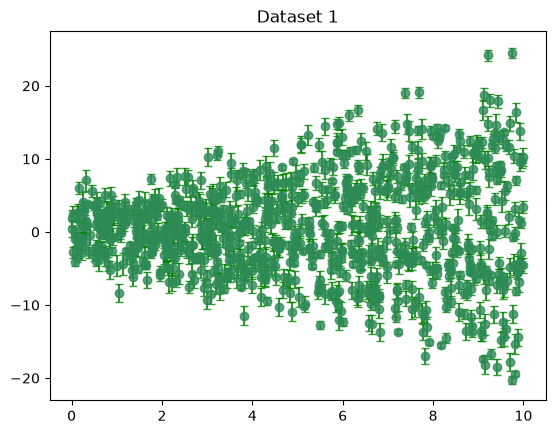

In [45]:
dataset_1 = []
points_1 = []
x_1 = []
y_1 = []
sigma_1 = []

with open('data1.csv', 'r') as data_1:
    reader = csv.reader(data_1)
    header = next(reader)
    for row in reader:
        dataset_1.append(row[0])
        points_1.append(row[1])
        x_1.append(row[2])
        y_1.append(row[3])
        sigma_1.append(row[4])
    
print(f'X values range from {x_1[0]} to {x_1[-1]}'
      f'Y values range from {y_1[0]} to {y_1[-1]}')

x_1 = np.array(x_1, dtype=float)
y_1 = np.array(y_1, dtype=float)
sigma_1 = np.array(sigma_1, dtype=float)

plt.errorbar(x_1, y_1, yerr=sigma_1, fmt='o', color='seagreen', 
             ecolor='green', capsize=3, alpha=0.8)
plt.title('Dataset 1')

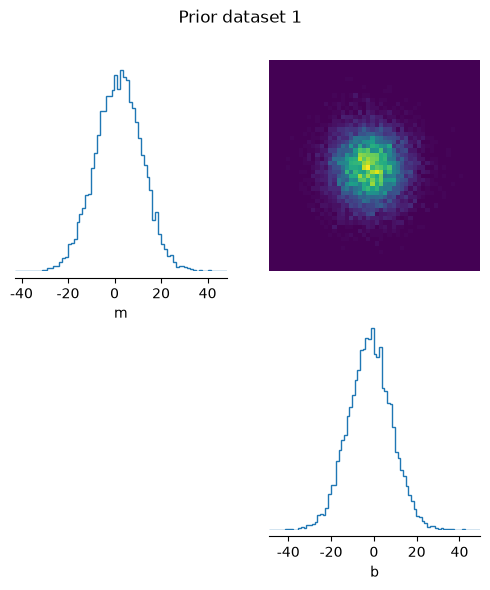

In [46]:
from torch.distributions import Normal, Independent
prior_1 = Independent(Normal(
    loc=torch.tensor([1.7, -2], dtype=torch.float32),
    scale=torch.tensor([10, 10], dtype=torch.float32)
), 1)

prior_samples1 = prior_1.sample((10000,))

fig, ax = pairplot(
    prior_samples1,
    labels=["m", "b"],
    figsize=(6, 6)
)
plt.suptitle("Prior dataset 1")
plt.show()

 Neural network successfully converged after 123 epochs.

  0%|          | 0/8000 [00:00<?, ?it/s]

True coefficients: m=0.1, b=0
Posterior mean coefficients: m=0.018, b=0.439


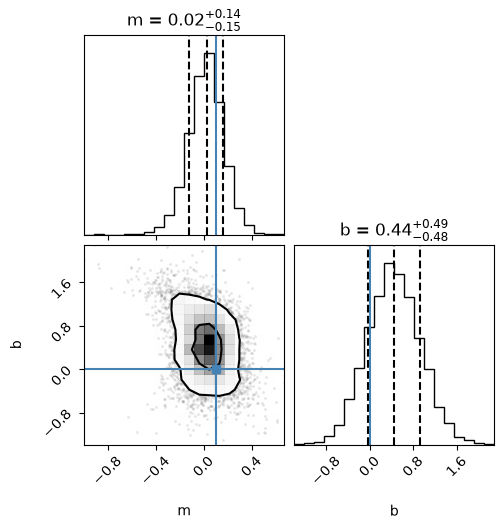

In [38]:
n_points = len(x_1)
def simulator(theta):
    coef_a, coef_b, = theta[0].item(), theta[1].item(), 
    sim_noise = np.random.normal(0, sigma_1, n_points)
    y_sim = coef_a * x_1 + coef_b  + sim_noise
    return torch.tensor(y_sim, dtype=torch.float32)

n_simulations = 2000
theta_train = prior_1.sample((n_simulations,))
x_train = torch.stack([simulator(theta) for theta in theta_train])

inference = NPE(prior=prior_1)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

observation = torch.tensor(y_1, dtype=torch.float32)
posterior_samples = posterior.sample((8000,), x=observation)


#Make corner plot
flat_samples = posterior_samples.numpy()

m = 0.1
b = 0
labels = ["m", "b"]
truths = [m, b]

fig = cp.corner(flat_samples[:, :2], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = posterior_samples.mean(dim=0)
print(f"True coefficients: m={m}, b={b}")
print(f"Posterior mean coefficients: m={posterior_mean[0]:.3f}, b={posterior_mean[1]:.3f}")

Data Set 2 Analysis

X values range from 0.149525 to 9.656906Y values range from 5.734863 to 12.417222


Text(0.5, 1.0, 'Dataset 2')

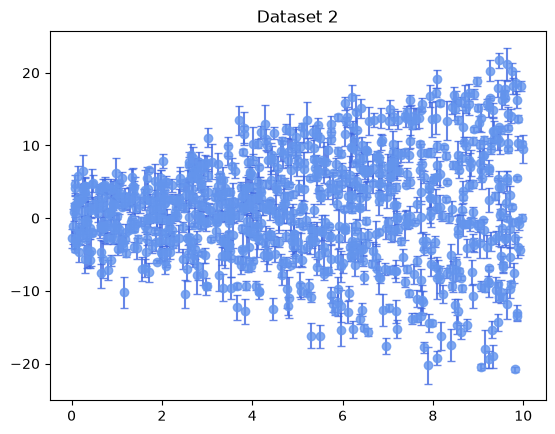

In [43]:
dataset_2 = []
points_2 = []
x_2 = []
y_2 = []
sigma_2 = []

with open('data2.csv', 'r') as data_2:
    reader = csv.reader(data_2)
    header = next(reader)
    for row in reader:
        dataset_2.append(row[0])
        points_2.append(row[1])
        x_2.append(row[2])
        y_2.append(row[3])
        sigma_2.append(row[4])
    
print(f'X values range from {x_2[0]} to {x_2[-1]}'
      f'Y values range from {y_2[0]} to {y_2[-1]}')

x_2 = np.array(x_2, dtype=float)
y_2 = np.array(y_2, dtype=float)
sigma_2 = np.array(sigma_2, dtype=float)

plt.errorbar(x_2, y_2, yerr=sigma_2, fmt='o', color='cornflowerblue', 
             ecolor='royalblue', capsize=3, alpha=0.8)
plt.title("Dataset 2")

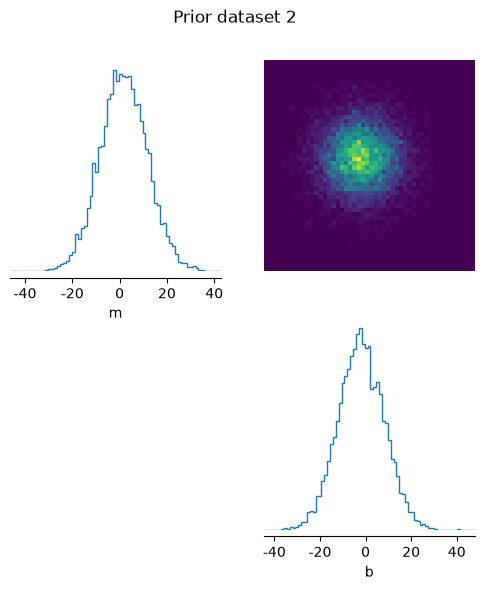

In [47]:
prior_2 = Independent(Normal(
    loc=torch.tensor([1.7, -2], dtype=torch.float32),
    scale=torch.tensor([10, 10], dtype=torch.float32)
), 1)

prior_samples2 = prior_2.sample((10000,))

fig, ax = pairplot(
    prior_samples2,
    labels=["m", "b"],
    figsize=(6, 6)
)
plt.suptitle("Prior dataset 2")
plt.show()

 Neural network successfully converged after 113 epochs.

  0%|          | 0/8000 [00:00<?, ?it/s]

True coefficients: m=0.1, b=0
Posterior mean coefficients: m=0.207, b=0.259


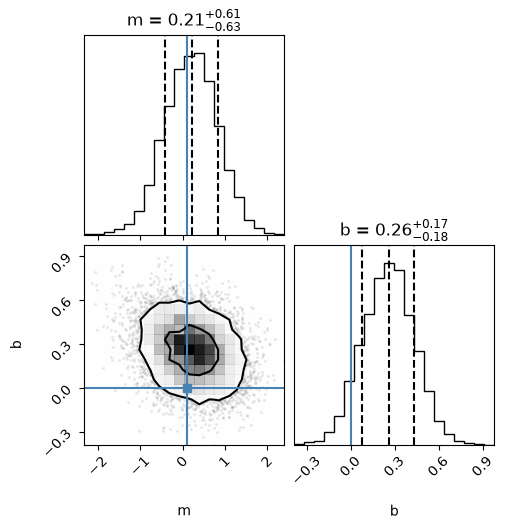

In [48]:
n_points = len(x_2)
def simulator(theta):
    coef_a, coef_b, = theta[0].item(), theta[1].item(), 
    sim_noise = np.random.normal(0, sigma_2, n_points)
    y_sim = coef_a * x_2 + coef_b  + sim_noise
    return torch.tensor(y_sim, dtype=torch.float32)

n_simulations = 2000
theta_train = prior_2.sample((n_simulations,))
x_train = torch.stack([simulator(theta) for theta in theta_train])

inference = NPE(prior=prior_2)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

observation = torch.tensor(y_2, dtype=torch.float32)
posterior_samples = posterior.sample((8000,), x=observation)


#Make corner plot
flat_samples = posterior_samples.numpy()

m = 0.1
b = 0
labels = ["m", "b"]
truths = [m, b]

fig = cp.corner(flat_samples[:, :2], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = posterior_samples.mean(dim=0)
print(f"True coefficients: m={m}, b={b}")
print(f"Posterior mean coefficients: m={posterior_mean[0]:.3f}, b={posterior_mean[1]:.3f}")